## Objective
Understand the internal structure of the Visual Genome (VG150-curated) dataset and determine
how images, objects, bounding boxes, and relationships are represented for relationship
prediction.

In [2]:
import h5py
file = h5py.File("C:\\Users\\psytr\\Desktop\\Projects\\scene_graph\\datasets\\visual_genome\\VG-SGG.h5", "r") # r = read mode
print(list(file.keys()))

['boxes_1024', 'boxes_512', 'img_to_first_box', 'img_to_first_rel', 'img_to_last_box', 'img_to_last_rel', 'labels', 'predicates', 'relationships', 'split', 'split_rel']


In [3]:
for i in file.keys():
    dataset=file[i]
    print(f"{i}")
    print(f"Shape: {dataset.shape}")
    print(f"Data type: {dataset.dtype}")
    print('-'*50)

boxes_1024
Shape: (1441984, 4)
Data type: int32
--------------------------------------------------
boxes_512
Shape: (1441984, 4)
Data type: int32
--------------------------------------------------
img_to_first_box
Shape: (108073,)
Data type: int32
--------------------------------------------------
img_to_first_rel
Shape: (108073,)
Data type: int32
--------------------------------------------------
img_to_last_box
Shape: (108073,)
Data type: int32
--------------------------------------------------
img_to_last_rel
Shape: (108073,)
Data type: int32
--------------------------------------------------
labels
Shape: (1441984, 1)
Data type: int64
--------------------------------------------------
predicates
Shape: (636175, 1)
Data type: int64
--------------------------------------------------
relationships
Shape: (636175, 2)
Data type: int32
--------------------------------------------------
split
Shape: (108073,)
Data type: int32
--------------------------------------------------
split_rel
Sh

In [4]:
for key in file.keys():
    dataset=file[key]
    print(key)
    print(dataset[:5])

boxes_1024
[[588 332 102 434]
 [557 588 920 338]
 [339 487  93 341]
 [658 464  95 126]
 [436 429  54  45]]
boxes_512
[[293 165  51 217]
 [278 293 460 169]
 [169 243  47 171]
 [329 231  48  63]
 [217 214  27  23]]
img_to_first_box
[ 0 23 41 56 68]
img_to_first_rel
[ 0 25 36 47 55]
img_to_last_box
[22 40 55 67 82]
img_to_last_rel
[24 35 46 54 62]
labels
[[ 35]
 [126]
 [ 95]
 [ 30]
 [ 14]]
predicates
[[48]
 [30]
 [20]
 [20]
 [48]]
relationships
[[ 2 11]
 [ 5  6]
 [ 2  7]
 [ 9 10]
 [ 2 11]]
split
[0 0 0 0 0]
split_rel
[0 0 0 0 0]


### Each image has avg of 13 boxes and 6 relationships

In [5]:
import json
with open("C:\\Users\\psytr\\Desktop\\Projects\\scene_graph\\datasets\\visual_genome\\VG-SGG-dicts.json","r") as f:
    vg_dict = json.load(f)
    print(vg_dict.keys())

dict_keys(['label_to_idx', 'idx_to_label', 'predicate_to_idx', 'idx_to_predicate', 'predicate_count', 'object_count'])


In [6]:
for key, value in vg_dict.items():
    print("-" * 60)
    print(key)
    print(type(value))

    if isinstance(value, dict):
        print("Length:", len(value))
        # first 10 entries
        for i, (k, v) in enumerate(value.items()):
            print(k, "->", v)
            if i == 9:
                break
    elif isinstance(value, list):
        print("Length:", len(value))
        print(value[:10])
    else:
        print(value)

------------------------------------------------------------
label_to_idx
<class 'dict'>
Length: 150
air -> 1
airplane -> 2
animal -> 3
arm -> 4
back -> 5
background -> 6
bag -> 7
banana -> 8
basket -> 9
beach -> 10
------------------------------------------------------------
idx_to_label
<class 'dict'>
Length: 150
1 -> air
2 -> airplane
3 -> animal
4 -> arm
5 -> back
6 -> background
7 -> bag
8 -> banana
9 -> basket
10 -> beach
------------------------------------------------------------
predicate_to_idx
<class 'dict'>
Length: 50
above -> 1
across -> 2
against -> 3
along -> 4
and -> 5
at -> 6
attached to -> 7
behind -> 8
between -> 9
carrying -> 10
------------------------------------------------------------
idx_to_predicate
<class 'dict'>
Length: 50
1 -> above
2 -> across
3 -> against
4 -> along
5 -> and
6 -> at
7 -> attached to
8 -> behind
9 -> between
10 -> carrying
------------------------------------------------------------
predicate_count
<class 'dict'>
Length: 50
on -> 567069
in

In [7]:
labels = file["labels"]
relationships = file["relationships"]
predicates = file["predicates"]

r = 1334

subject_box = int(relationships[r][0])
object_box = int(relationships[r][1])

predicate = int(predicates[r][0])

subject_label = int(labels[subject_box][0])
object_label = int(labels[object_box][0])

print("Relationship:", relationships[r])
print("Predicate:", predicate)
print(
 vg_dict["idx_to_label"][str(subject_label)],
 "--",
 vg_dict["idx_to_predicate"][str(predicate)],
 "-->",
 vg_dict["idx_to_label"][str(object_label)]
)

Relationship: [2987 2985]
Predicate: 32
sky -- over --> mountain


In [13]:
image_idx = 0

first_box = int(file["img_to_first_box"][image_idx])
last_box = int(file["img_to_last_box"][image_idx])

first_rel = int(file["img_to_first_rel"][image_idx])
last_rel = int(file["img_to_last_rel"][image_idx])

print("Boxes:", first_box, "to", last_box)
print("Relationships:", first_rel, "to", last_rel)

Boxes: 0 to 22
Relationships: 0 to 24


In [14]:
print("OBJECTS")
print("-" * 60)

for box_idx in range(first_box, last_box + 1):

    label_idx = int(file["labels"][box_idx][0])

    label = vg_dict["idx_to_label"][str(label_idx)]

    box = file["boxes_1024"][box_idx]

    print(f"[{box_idx}] {label}")
    print(f"Box : {box.tolist()}")
    print()

OBJECTS
------------------------------------------------------------
[0] clock
Box : [588, 332, 102, 434]

[1] street
Box : [557, 588, 920, 338]

[2] person
Box : [339, 487, 93, 341]

[3] car
Box : [658, 464, 95, 126]

[4] bike
Box : [436, 429, 54, 45]

[5] sign
Box : [205, 131, 113, 233]

[6] building
Box : [140, 344, 280, 687]

[7] shirt
Box : [345, 433, 76, 130]

[8] street
Box : [738, 509, 564, 299]

[9] car
Box : [962, 547, 117, 223]

[10] back
Box : [964, 541, 86, 218]

[11] shoe
Box : [528, 636, 59, 44]

[12] person
Box : [524, 497, 125, 322]

[13] pant
Box : [336, 566, 49, 152]

[14] jacket
Box : [511, 439, 114, 125]

[15] pant
Box : [522, 553, 70, 164]

[16] sidewalk
Box : [469, 526, 64, 242]

[17] wall
Box : [86, 341, 172, 683]

[18] tree
Box : [629, 356, 776, 713]

[19] arm
Box : [489, 388, 41, 56]

[20] shirt
Box : [514, 432, 48, 85]

[21] road
Box : [773, 516, 436, 280]

[22] window
Box : [880, 98, 222, 190]



In [15]:
print("RELATIONSHIPS")
print("-" * 60)

for rel_idx in range(first_rel, last_rel + 1):

    subject_box = int(file["relationships"][rel_idx][0])
    object_box = int(file["relationships"][rel_idx][1])

    predicate_idx = int(file["predicates"][rel_idx][0])

    subject_label = int(file["labels"][subject_box][0])
    object_label = int(file["labels"][object_box][0])

    subject = vg_dict["idx_to_label"][str(subject_label)]
    predicate = vg_dict["idx_to_predicate"][str(predicate_idx)]
    obj = vg_dict["idx_to_label"][str(object_label)]

    print(
        f"{subject} ({subject_box}) "
        f"-- {predicate} --> "
        f"{obj} ({object_box})"
    )

RELATIONSHIPS
------------------------------------------------------------
person (2) -- wearing --> shoe (11)
sign (5) -- on --> building (6)
person (2) -- has --> shirt (7)
car (9) -- has --> back (10)
person (2) -- wearing --> shoe (11)
person (12) -- has --> shoe (11)
person (2) -- has --> shirt (7)
person (2) -- wearing --> pant (13)
person (12) -- has --> jacket (14)
person (12) -- has --> pant (15)
bike (4) -- parked on --> street (1)
car (9) -- parked on --> street (8)
bike (4) -- on --> sidewalk (16)
person (2) -- wearing --> shirt (7)
bike (4) -- near --> tree (18)
person (12) -- wearing --> shoe (11)
bike (4) -- near --> tree (18)
shirt (7) -- on --> person (2)
person (2) -- in --> shirt (7)
person (2) -- wearing --> pant (13)
tree (18) -- near --> street (8)
bike (4) -- behind --> person (2)
tree (18) -- near --> street (1)
person (12) -- wearing --> jacket (14)
building (6) -- with --> window (22)


In [16]:
print("Number of objects :", last_box - first_box + 1)
print("Number of relationships :", last_rel - first_rel + 1)

Number of objects : 23
Number of relationships : 25


In [18]:
scene = {
    "image_index": image_idx,
    "boxes": file["boxes_1024"][first_box:last_box + 1],
    "labels": file["labels"][first_box:last_box + 1],
    "relationships": file["relationships"][first_rel:last_rel + 1],
    "predicates": file["predicates"][first_rel:last_rel + 1],
}
scene.keys()

dict_keys(['image_index', 'boxes', 'labels', 'relationships', 'predicates'])

In [19]:
with open("../datasets/visual_genome/image_data.json", "r") as f:
    image_data = json.load(f)

In [25]:
print(len(image_data))
print(type(image_data))
print(type(image_data[0]),"\n")
from pprint import pprint

pprint(image_data[0])

108077
<class 'list'>
<class 'dict'> 

{'coco_id': None,
 'flickr_id': None,
 'height': 600,
 'image_id': 1,
 'url': 'https://cs.stanford.edu/people/rak248/VG_100K_2/1.jpg',
 'width': 800}


In [26]:
image_idx = 0

info = image_data[image_idx]

print(f"Image Index : {image_idx}")
print(f"Image ID    : {info['image_id']}")
print(f"Width       : {info['width']}")
print(f"Height      : {info['height']}")
print(f"URL         : {info['url']}")

Image Index : 0
Image ID    : 1
Width       : 800
Height      : 600
URL         : https://cs.stanford.edu/people/rak248/VG_100K_2/1.jpg


In [27]:
from pathlib import Path
url = info["url"]

filename = Path(url).name          # 1.jpg
folder = Path(url).parent.name     # VG_100K_2

print(filename)
print(folder)

1.jpg
VG_100K_2


In [28]:
DATASET_ROOT = Path("../datasets/visual_genome")
image_path = DATASET_ROOT / folder / filename

print(image_path)
print(image_path.exists())

..\datasets\visual_genome\VG_100K_2\1.jpg
True


(800, 600)


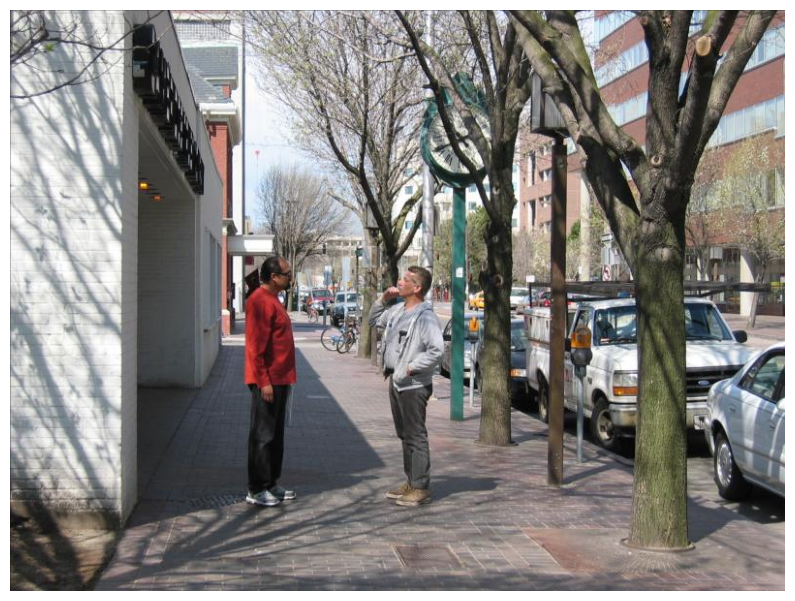

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

print(img.size)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
boxes = file["boxes_1024"]

for i in range(first_box, first_box + 5):
    print(boxes[i])

[588 332 102 434]
[557 588 920 338]
[339 487  93 341]
[658 464  95 126]
[436 429  54  45]


### All Functions to get image data to build compelte reconstrction of an image

In [32]:
from pathlib import Path

DATASET_ROOT = Path("../datasets/visual_genome")

def get_image_info(image_idx):
    info = image_data[image_idx]

    folder = Path(info["url"]).parent.name
    filename = Path(info["url"]).name

    image_path = DATASET_ROOT / folder / filename

    return {
        "image_index": image_idx,
        "image_id": info["image_id"],
        "width": info["width"],
        "height": info["height"],
        "folder": folder,
        "filename": filename,
        "path": image_path
    }

In [33]:
info = get_image_info(0)
info

{'image_index': 0,
 'image_id': 1,
 'width': 800,
 'height': 600,
 'folder': 'VG_100K_2',
 'filename': '1.jpg',
 'path': WindowsPath('../datasets/visual_genome/VG_100K_2/1.jpg')}

In [34]:
def get_objects(image_idx):

    first_box = int(file["img_to_first_box"][image_idx])
    last_box = int(file["img_to_last_box"][image_idx])

    objects = []

    for box_idx in range(first_box, last_box + 1):

        label_idx = int(file["labels"][box_idx][0])

        label = vg_dict["idx_to_label"][str(label_idx)]

        x, y, w, h = file["boxes_1024"][box_idx]

        objects.append({
            "box_index": box_idx,
            "label_index": label_idx,
            "label": label,
            "bbox_1024": (int(x), int(y), int(w), int(h))
        })

    return objects

In [35]:
objects = get_objects(0)

print(len(objects))
objects[:3]

23


[{'box_index': 0,
  'label_index': 35,
  'label': 'clock',
  'bbox_1024': (588, 332, 102, 434)},
 {'box_index': 1,
  'label_index': 126,
  'label': 'street',
  'bbox_1024': (557, 588, 920, 338)},
 {'box_index': 2,
  'label_index': 95,
  'label': 'person',
  'bbox_1024': (339, 487, 93, 341)}]

In [36]:
def get_relationships(image_idx):

    first_rel = int(file["img_to_first_rel"][image_idx])
    last_rel = int(file["img_to_last_rel"][image_idx])

    relationships = []

    for rel_idx in range(first_rel, last_rel + 1):

        subject_box = int(file["relationships"][rel_idx][0])
        object_box = int(file["relationships"][rel_idx][1])

        predicate_idx = int(file["predicates"][rel_idx][0])

        relationships.append({

            "subject_box": subject_box,
            "object_box": object_box,

            "predicate_index": predicate_idx,

            "predicate": vg_dict["idx_to_predicate"][str(predicate_idx)]
        })

    return relationships

In [ ]:
def print_scene(image_idx):

    info = get_image_info(image_idx)
    objects = get_objects(image_idx)
    relationships = get_relationships(image_idx)

    object_lookup = {}

    for obj in objects:
        object_lookup[obj["box_index"]] = obj

    print("=" * 70)
    print(f"Image Index : {info['image_index']}")
    print(f"Image ID    : {info['image_id']}")
    print("=" * 70)

    print("\nOBJECTS\n")

    for i, obj in enumerate(objects):

        print(f"[{i}] {obj['label']}")
        print(f"Object Index   : {obj['box_index']}")
        print(f"Box (xc,yc,w,h): {obj['bbox_1024']}")
        print()

    print("\nRELATIONSHIPS\n")

    for rel in relationships:

        subject = object_lookup[rel["subject_box"]]["label"]
        obj = object_lookup[rel["object_box"]]["label"]

        print(
            f"{subject}"
            f" -- {rel['predicate']} --> "
            f"{obj}"
        )

In [38]:
print_scene(0)

Image Index : 0
Image ID    : 1

OBJECTS

[0] clock
Global Box : 0
Box        : (588, 332, 102, 434)

[1] street
Global Box : 1
Box        : (557, 588, 920, 338)

[2] person
Global Box : 2
Box        : (339, 487, 93, 341)

[3] car
Global Box : 3
Box        : (658, 464, 95, 126)

[4] bike
Global Box : 4
Box        : (436, 429, 54, 45)

[5] sign
Global Box : 5
Box        : (205, 131, 113, 233)

[6] building
Global Box : 6
Box        : (140, 344, 280, 687)

[7] shirt
Global Box : 7
Box        : (345, 433, 76, 130)

[8] street
Global Box : 8
Box        : (738, 509, 564, 299)

[9] car
Global Box : 9
Box        : (962, 547, 117, 223)

[10] back
Global Box : 10
Box        : (964, 541, 86, 218)

[11] shoe
Global Box : 11
Box        : (528, 636, 59, 44)

[12] person
Global Box : 12
Box        : (524, 497, 125, 322)

[13] pant
Global Box : 13
Box        : (336, 566, 49, 152)

[14] jacket
Global Box : 14
Box        : (511, 439, 114, 125)

[15] pant
Global Box : 15
Box        : (522, 553, 70, 164)

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

def load_image(image_idx):

    info = get_image_info(image_idx)

    img = Image.open(info["path"])

    return img

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

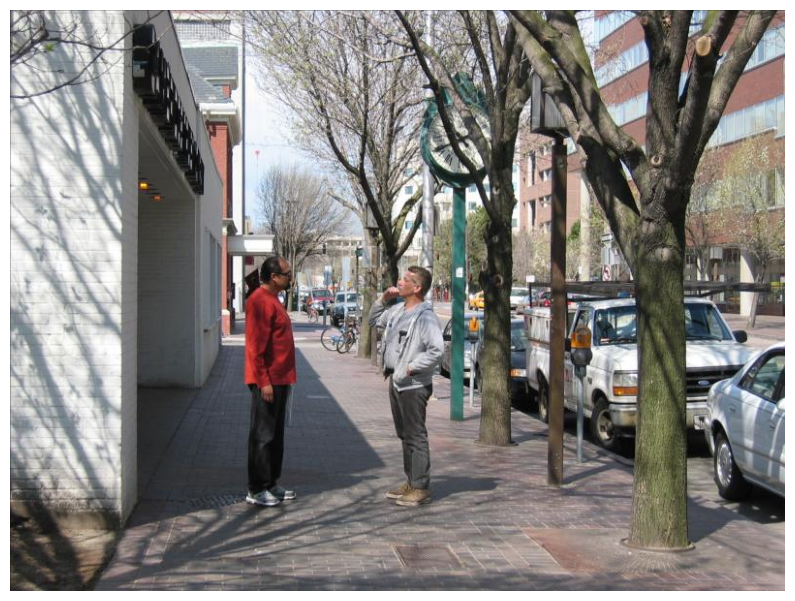

In [40]:
img = load_image(0)

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")

In [42]:
def scale_box_to_original(box, width, height):

    x, y, w, h = box

    scale = 1024 / max(width, height)

    x /= scale
    y /= scale
    w /= scale
    h /= scale

    return x, y, w, h

In [50]:
def draw_box_on_image(image_idx, num_objects=5):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    img = load_image(image_idx)
    info = get_image_info(image_idx)
    objects = get_objects(image_idx)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)

    colors = [
        "red",
        "lime",
        "blue",
        "yellow",
        "magenta",
        "cyan",
        "orange",
        "white"
    ]

    for i, obj in enumerate(objects[:num_objects]):

        x, y, w, h = scale_box_to_original(
            obj["bbox_1024"],
            info["width"],
            info["height"]
        )

        # Convert center -> top-left
        x -= w / 2
        y -= h / 2

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            edgecolor=colors[i % len(colors)],
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y - 5,
            f"[{i}] {obj['label']}",
            color=colors[i % len(colors)],
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=2)
        )

    ax.set_title(f"Image {image_idx} - First {num_objects} Objects")
    ax.axis("off")

    plt.show()

Image Index : 0
Image ID    : 1

OBJECTS

[0] clock
Global Box : 0
Box        : (588, 332, 102, 434)

[1] street
Global Box : 1
Box        : (557, 588, 920, 338)

[2] person
Global Box : 2
Box        : (339, 487, 93, 341)

[3] car
Global Box : 3
Box        : (658, 464, 95, 126)

[4] bike
Global Box : 4
Box        : (436, 429, 54, 45)

[5] sign
Global Box : 5
Box        : (205, 131, 113, 233)

[6] building
Global Box : 6
Box        : (140, 344, 280, 687)

[7] shirt
Global Box : 7
Box        : (345, 433, 76, 130)

[8] street
Global Box : 8
Box        : (738, 509, 564, 299)

[9] car
Global Box : 9
Box        : (962, 547, 117, 223)

[10] back
Global Box : 10
Box        : (964, 541, 86, 218)

[11] shoe
Global Box : 11
Box        : (528, 636, 59, 44)

[12] person
Global Box : 12
Box        : (524, 497, 125, 322)

[13] pant
Global Box : 13
Box        : (336, 566, 49, 152)

[14] jacket
Global Box : 14
Box        : (511, 439, 114, 125)

[15] pant
Global Box : 15
Box        : (522, 553, 70, 164)

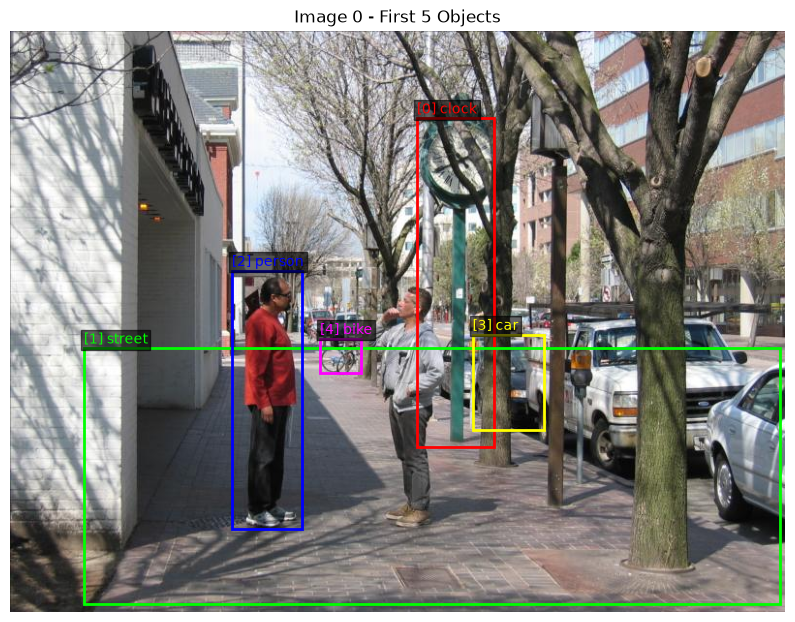

In [51]:
print_scene(0)
draw_box_on_image(0)

## All exploration is done, and a python system built (Dataset SDK) . Refer ./datasets/visual_genome/testing_dataset_sdk.py